In [13]:
import pandas as pd
df = pd.read_csv('dataset_06_equipment_failure_warning.csv')
df.head()

,temperature,vibration,pressure,runtime_hours,maintenance_gap_days,power_draw,target
0,62.10,1.01,86.17,1.00,16,63.81,0
1,78.78,0.10,95.62,17.13,54,298.61,1
2,76.70,5.28,130.00,19.59,29,245.18,1
3,88.05,4.22,93.83,1.04,52,328.36,1
4,71.58,6.59,103.01,19.12,43,345.48,0


In [14]:
print(df.shape)
print(df.dtypes)
df.describe()

(1000, 7)
temperature             float64
vibration               float64
pressure                float64
runtime_hours           float64
maintenance_gap_days      int64
power_draw              float64
target                    int64
dtype: object


,temperature,vibration,pressure,runtime_hours,maintenance_gap_days,power_draw,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,70.175340,3.982960,100.048280,10.832150,30.271000,186.449680,0.50000
std,12.139762,1.675728,17.907478,7.146326,18.104788,150.152338,0.50025
min,30.320000,0.100000,40.190000,1.000000,0.000000,20.730000,0.00000
25%,61.605000,2.870000,87.585000,4.957500,15.000000,93.352500,0.00000
50%,70.475000,3.935000,100.475000,10.520000,30.000000,144.840000,0.50000
75%,78.167500,5.130000,112.477500,15.935000,47.000000,240.855000,1.00000
max,109.320000,8.370000,158.570000,34.860000,60.000000,1940.660000,1.00000


In [15]:
print("Target distribution:\n", df['target'].value_counts(normalize=True))

Target distribution:
 target
0    0.5
1    0.5
Name: proportion, dtype: float64


In [16]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nClass balance:\n", df['target'].value_counts())

Missing values:
 temperature             0
vibration               0
pressure                0
runtime_hours           0
maintenance_gap_days    0
power_draw              0
target                  0
dtype: int64

Duplicate rows: 0

Class balance:
 target
0    500
1    500
Name: count, dtype: int64


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('target', axis=1)
y = df['target']

# Train/test split BEFORE scaling to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # fit only on train

In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [[ 0.54624414 -0.36511832  0.54964651 -0.41469128  0.44187587 -0.45866718]]
Intercept: [-0.01329343]


In [19]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score, RocCurveDisplay)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.715
Precision: 0.7415730337078652
Recall: 0.66
F1 Score: 0.6984126984126984
ROC-AUC: 0.7787999999999999

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.77      0.73       100
           1       0.74      0.66      0.70       100

    accuracy                           0.71       200
   macro avg       0.72      0.72      0.71       200
weighted avg       0.72      0.71      0.71       200



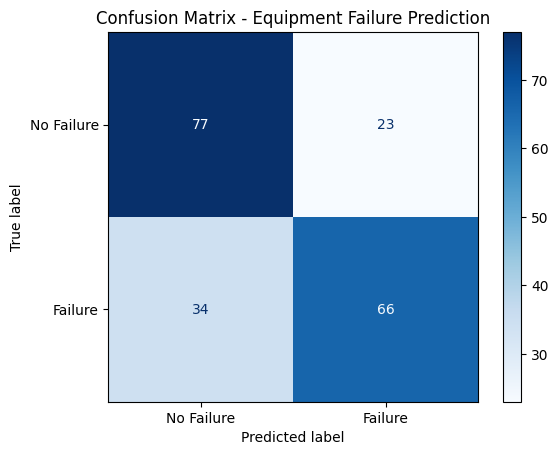

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Failure', 'Failure']).plot(cmap='Blues')
plt.title("Confusion Matrix - Equipment Failure Prediction")
plt.show()

In [21]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(coef_df)

                Feature  Coefficient
2              pressure     0.549647
0           temperature     0.546244
5            power_draw    -0.458667
4  maintenance_gap_days     0.441876
3         runtime_hours    -0.414691
1             vibration    -0.365118


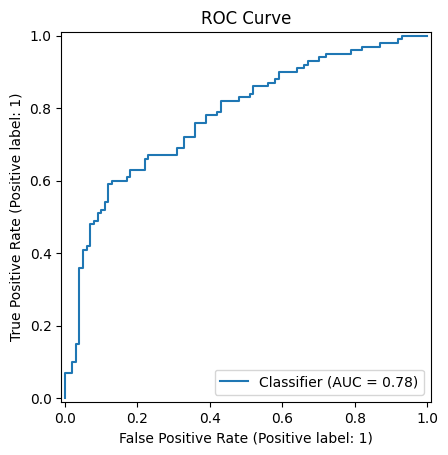

In [22]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve")
plt.show()